In [1]:
import pandas as pd

# Load the dataset from your directory
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

# Check total rows and columns
print("Dataset Shape (Rows, Columns):", df.shape)

# Display the first 5 rows focusing on core attributes
print("\nSample Data Preview:")
print(df[['Farm_ID', 'State', 'Crop', 'Season', 'Farm_Area_Hectares', 'Yield_Tonnes_Ha', 'Profit_INR']].head())

# Check data types
print("\nColumn Data Types:")
print(df.dtypes)

Dataset Shape (Rows, Columns): (4000, 28)

Sample Data Preview:
   Farm_ID           State    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh   Wheat  Kharif                0.53   
1  SF10002     Maharashtra   Maize  Kharif                6.53   
2  SF10003       Telangana  Pulses    Rabi                4.86   
3  SF10004       Telangana    Rice  Kharif                4.50   
4  SF10005       Karnataka   Maize    Zaid                4.21   

   Yield_Tonnes_Ha  Profit_INR  
0             2.46      -11852  
1             0.30     -451950  
2             0.52     -124744  
3             1.84      -95704  
4             2.21     -144352  

Column Data Types:
Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                f

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

# Step A: Check total missing values across the dataset
print("Total missing values before cleaning:", df.isnull().sum().sum())

# Step B: Impute missing numerical values safely (avoids ChainedAssignmentError)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# Step C: Verify that all missing values have been successfully cleared
print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values before cleaning: 120
Total missing values after cleaning: 0


In [4]:
import pandas as pd
import numpy as np

# Load dataset and clean missing values (from Step 2)
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 1. Overall Summary Statistics for Key Metrics
print("--- Overall Summary Statistics ---")
summary_stats = df[['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Rainfall_mm']].describe()
print(summary_stats)

# 2. Grouping Performance by Season
print("\n--- Performance Breakdown by Season ---")
seasonal_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Used_m3': 'mean',
    'Profit_INR': 'mean',
    'Rainfall_mm': 'mean'
}).reset_index()
print(seasonal_summary)

--- Overall Summary Statistics ---
       Yield_Tonnes_Ha    Profit_INR  Water_Used_m3  Rainfall_mm
count      4000.000000  4.000000e+03    4000.000000  4000.000000
mean          5.242350  1.115565e+05    6045.570250   600.922825
std          13.311549  5.450819e+05    5572.944306   287.193381
min           0.300000 -1.019223e+06     128.000000    80.000000
25%           1.050000 -1.487318e+05    2268.750000   371.575000
50%           1.740000  3.673000e+03    4435.000000   582.000000
75%           2.830000  2.161878e+05    7829.750000   831.975000
max         101.440000  4.345421e+06   40902.000000  1395.200000

--- Performance Breakdown by Season ---
   Season  Yield_Tonnes_Ha  Water_Used_m3     Profit_INR  Rainfall_mm
0  Kharif         5.628612    6102.201237  178914.647555   849.199663
1    Rabi         5.039435    5846.987093   87689.470191   437.615366
2    Zaid         4.641313    6419.893939  -24804.824916   304.654714


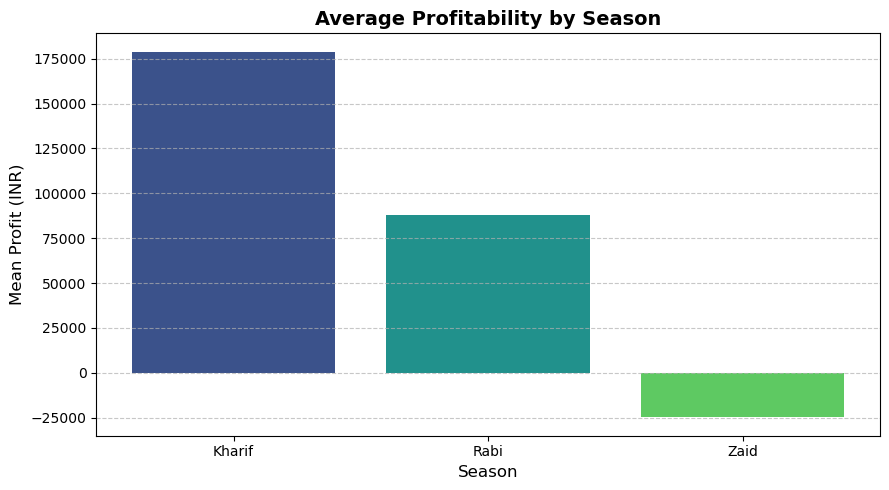

<ipython-input-8-25dc88e5c140>:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(crop_groups, labels=crop_labels, patch_artist=True)


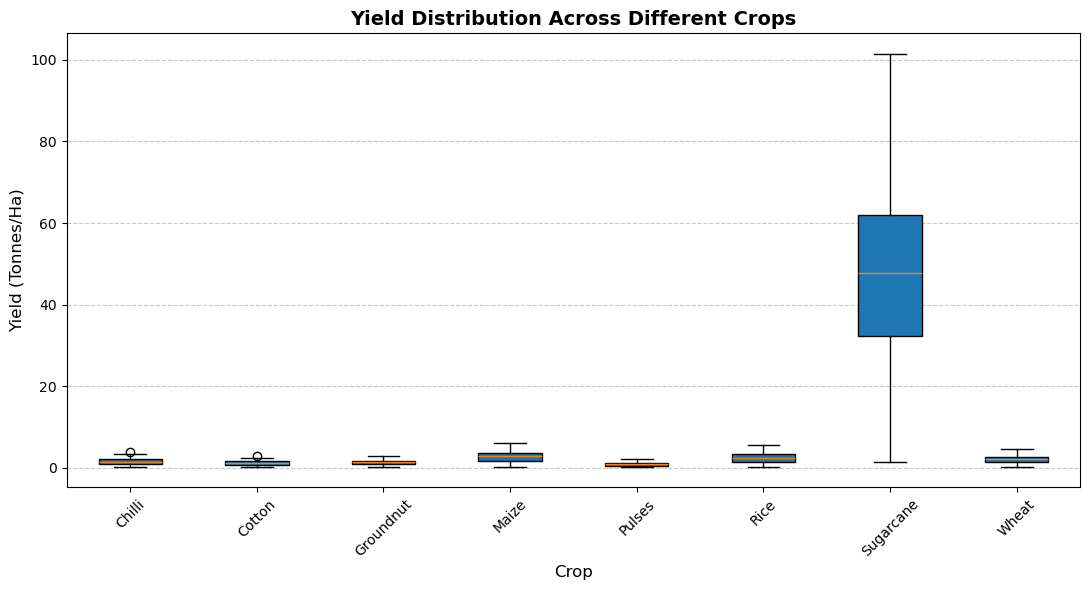

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset and clean missing values
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Plot 1: Average Profitability by Season (Bar Chart)
seasonal_profit = df.groupby('Season')['Profit_INR'].mean()

plt.figure(figsize=(9, 5))
plt.bar(seasonal_profit.index, seasonal_profit.values, color=['#3b528b', '#21918c', '#5ec962'])
plt.title('Average Profitability by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Mean Profit (INR)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('seasonal_profit_analysis.png')
plt.show()

# Plot 2: Yield Distribution Across Crops (Box Plot)
crop_groups = [group['Yield_Tonnes_Ha'].values for name, group in df.groupby('Crop')]
crop_labels = [name for name, group in df.groupby('Crop')]

plt.figure(figsize=(11, 6))
plt.boxplot(crop_groups, labels=crop_labels, patch_artist=True)
plt.title('Yield Distribution Across Different Crops', fontsize=14, fontweight='bold')
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('crop_yield_distribution.png')
plt.show()



In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load dataset and clean missing values
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 2. Define Features (X) and Target (y)
features = ['State', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 
            'Fertilizer_kg_ha', 'Water_Used_m3', 'Soil_Moisture_pct']
target = 'Profit_INR'

X = df[features]
y = df[target]

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Preprocessing categorical text features
categorical_cols = ['State', 'Crop', 'Season']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# 5. Create Pipeline with Random Forest Regressor
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 6. Train the Model
model.fit(X_train, y_train)

# 7. Evaluate Model Accuracy
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): INR {rmse:.2f}")

Model R-squared Score: 0.4815
Root Mean Squared Error (RMSE): INR 381406.18
